# Les partis extrémistes ont-ils une rhétorique plus populiste que les partis traditionnels ?
## Etude de la rhétorique populiste dans les programmes électoraux français (1973–1993)

## Structure
1. Setup & données
2. Méthode 1 : Similarité sémantique
3. Méthode 2 : NLI zero-shot
4. Résultats : Extrêmes vs Mainstream
5. Résultats : Évolution temporelle
6. Robustesse

## 1. Setup & données

Notebook écrit en Python 3.13.5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats
import re, zipfile, requests, warnings, pickle
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH       = 'archelect_search.csv'
YEARS_AVAILABLE = [1973, 1978, 1981, 1988, 1993]
GITLAB_REPO     = 'https://gitlab.teklia.com/ckermorvant/arkindex_archelec/-'
SEED            = 42
np.random.seed(SEED)
print('Imports OK')


Imports OK


In [2]:
import torch
DEVICE_S = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE   = 0 if torch.cuda.is_available() else -1
print(f'Device : {DEVICE_S}  (DEVICE={DEVICE})')

Device : cuda  (DEVICE=0)


In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df['annee'] = pd.to_datetime(df['date'], errors='coerce').dt.year
df = df[df['annee'].isin(YEARS_AVAILABLE)].reset_index(drop=True)
print(f'Corpus brut : {df.shape[0]} candidats × {df.shape[1]} colonnes')

FAMILLE_5 = {
    'Parti communiste français': 'Extrême gauche',
    'Lutte ouvrière': 'Extrême gauche',
    'Ligue communiste révolutionnaire': 'Extrême gauche',
    'Mouvement pour un parti des travailleurs': 'Extrême gauche',
    'Parti des travailleurs': 'Extrême gauche',
    'marxistes-léninistes': 'Extrême gauche',

    'Parti socialiste': 'Gauche',
    'Parti socialiste unifié': 'Gauche',
    'Les Verts': 'Gauche',
    'Verts': 'Gauche',
    'Génération écologie': 'Gauche',
    'Mouvement des radicaux de gauche': 'Gauche',
    'Mouvement des citoyens': 'Gauche',
    'Union démocratique bretonne': 'Gauche',
    'Front progressiste': 'Gauche',
    'Comités Juquin': 'Gauche',
    'Parti breton Strollad ar vro': 'Gauche',

    'Radical': 'Centre',
    'radical indépendant': 'Centre',
    'libéral': 'Centre',
    'libéraux': 'Centre',
    'Mouvement républicain populaire': 'Centre',
    'Centre démocrate': 'Centre',
    'Centre des démocrates sociaux': 'Centre',
    'Union pour la démocratie française': 'Centre',
    'Mouvement démocrate': 'Centre',
    'Parti radical': 'Centre',
    'Progrès et démocratie moderne': 'Centre',
    'Mouvement des réformateurs': 'Centre',
    'Réformateurs': 'Centre',
    'Mouvement des démocrates': 'Centre',
    'Rassemblement démocratique': 'Centre',
    'Démocratie chrétienne': 'Centre',

    'Rassemblement pour la République': 'Droite',
    'Républicains indépendants': 'Droite',
    'Union des républicains de progrès': 'Droite',
    'Centre national des indépendants et paysans': 'Droite',
    'Alliance populaire': 'Droite',
    'Chasse pêche nature traditions': 'Droite',
    'Parti libéral de France': 'Droite',
    'divers droite': 'Droite',
    
    'Front national': 'Extrême droite',
    'Parti des forces nouvelles': 'Extrême droite',
    'Parti ouvrier européen': 'Extrême droite',
}

COULEURS_5 = {
    'Extrême gauche': '#8B0000',
    'Gauche': '#E74C3C',
    'Centre': '#F39C12',
    'Droite': '#2980B9',
    'Extrême droite': '#1A252F',
}
ORDRE_FAMILLES = ['Extrême gauche', 'Gauche', 'Centre', 'Droite', 'Extrême droite']

def classifier_famille_5(s):
    if not isinstance(s, str): return None
    if s in FAMILLE_5: return FAMILLE_5[s]
    for part in s.split(';'):
        part = part.strip()
        if part in FAMILLE_5: return FAMILLE_5[part]
    sl = s.lower()
    if any(k in sl for k in ['front national', 'rassemblement national', 'fraternité française',
                               'parti des forces nouvelles', 'rassemblement européen de la liberté']):
        return 'Extrême droite'
    if any(k in sl for k in ['lutte ouvrière', 'ligue communiste', 'anticapitaliste',
                               'trotsk', 'lambertiste', 'parti des travailleurs']):
        return 'Extrême gauche'
    if 'communiste' in sl and 'anti' not in sl: return 'Extrême gauche'
    if 'marxiste' in sl and ('léniniste' in sl or 'maoïste' in sl): return 'Extrême gauche'
    if any(k in sl for k in ['socialiste', 'verts', 'écolog', 'insoumis', 'radicaux de gauche']): return 'Gauche'
    if re.search(r'\bgauche\b', sl): return 'Gauche'
    if any(k in sl for k in ['mouvement républicain populaire', 'démocratie chrétienne',
                               'progrès et démocratie', 'mouvement des réformateurs',
                               'udf', 'modem', 'mouvement démocrate']): return 'Centre'
    if any(k in sl for k in ['centre', 'démocrate', 'réformateur']) and 'gauche' not in sl: return 'Centre'
    if any(k in sl for k in ['républicain', 'gaulliste', 'cnip', 'ump', 'rpr',
                               'indépendants et paysans', 'alliance populaire']): return 'Droite'
    return None

df['famille'] = df['titulaire-soutien'].apply(classifier_famille_5)
df_valid = df.dropna(subset=['id', 'annee']).copy()
sample_df = df_valid.reset_index(drop=True)
print(f'Corpus final : {len(sample_df)} documents')
print(f'Coverage classification : {sample_df["famille"].notna().mean()*100:.1f}%')
print(sample_df['famille'].value_counts().reindex(ORDRE_FAMILLES))

Corpus brut : 21194 candidats × 43 colonnes
Corpus final : 21194 documents
Coverage classification : 76.2%
famille
Extrême gauche    4421
Gauche            4974
Centre            2062
Droite            3028
Extrême droite    1660
Name: count, dtype: int64


In [4]:
def clean_ocr(text):
    if not text: return ''
    text = re.sub(r'\x0c', '\n', text)
    return re.sub(r'\s+', ' ', text).strip()

def pretraiter(texte):
    if not isinstance(texte, str): return ''
    return ' '.join(texte.replace('\u2019', "'").replace('\u2018', "'").split())

ZIP_DIR  = Path('./zips')
PKL_PATH = ZIP_DIR / 'texts.pkl'
ZIP_DIR.mkdir(exist_ok=True)

if PKL_PATH.exists():
    with open(PKL_PATH, 'rb') as f:
        TEXT_CACHE = pickle.load(f)
    print(f'Cache textes chargé ({len(TEXT_CACHE)} docs).')
else:
    TEXT_CACHE = {}
    for yr in tqdm(YEARS_AVAILABLE, desc='Téléchargement / lecture'):
        zip_path = ZIP_DIR / f'{yr}_legislatives.zip'
        if not zip_path.exists():
            r = requests.get(f'{GITLAB_REPO}/raw/master/text_files/{yr}/legislatives.zip', timeout=120)
            r.raise_for_status()
            zip_path.write_bytes(r.content)
        with zipfile.ZipFile(zip_path) as z:
            for name in z.namelist():
                if name.endswith('.txt'):
                    doc_id = name.rsplit('/', 1)[-1].replace('.txt', '')
                    TEXT_CACHE[doc_id] = clean_ocr(z.read(name).decode('utf-8', errors='replace'))
    with open(PKL_PATH, 'wb') as f:
        pickle.dump(TEXT_CACHE, f)
    print(f'Textes sauvegardés → {PKL_PATH} ({len(TEXT_CACHE)} docs).')

sample_df['text'] = sample_df['id'].map(TEXT_CACHE).fillna('')
sample_df = sample_df[sample_df['text'].str.len() > 100].reset_index(drop=True)
sample_df['nb_mots'] = sample_df['text'].str.split().str.len()
print(f'Corpus avec texte : {len(sample_df)} docs | {sample_df["nb_mots"].mean():.0f} mots/doc en moyenne')

Cache textes chargé (21697 docs).
Corpus avec texte : 21167 docs | 712 mots/doc en moyenne


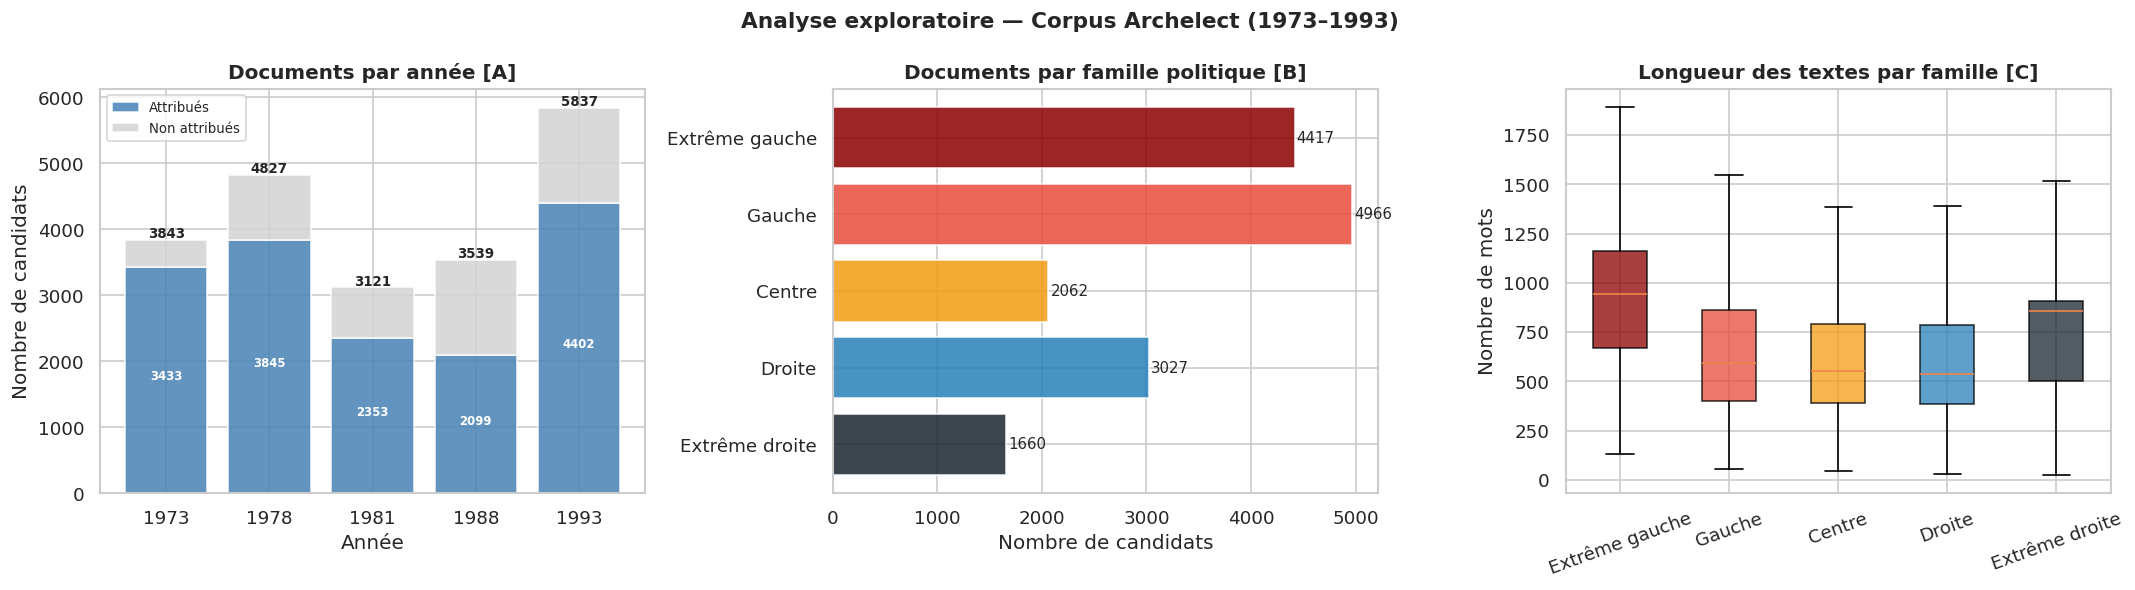

                 count   mean    50%     max
famille                                     
Centre          2062.0  621.0  551.0  2765.0
Droite          3027.0  625.0  535.0  2552.0
Extrême droite  1660.0  820.0  857.0  2651.0
Extrême gauche  4417.0  940.0  942.0  2667.0
Gauche          4966.0  656.0  593.0  2693.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Documents par année -- barre empilée attribués / non-attribués
counts_total   = sample_df['annee'].value_counts().sort_index()
counts_attrib  = sample_df[sample_df['famille'].notna()]['annee'].value_counts().sort_index()
counts_attrib  = counts_attrib.reindex(counts_total.index, fill_value=0)
counts_non_att = counts_total - counts_attrib
annees_str = counts_total.index.astype(str)

axes[0].bar(annees_str, counts_attrib.values,  color='steelblue', alpha=0.85, label='Attribués')
axes[0].bar(annees_str, counts_non_att.values, color='lightgray', alpha=0.85,
            bottom=counts_attrib.values, label='Non attribués')
axes[0].set_title('Documents par année [A]', fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre de candidats')
axes[0].legend(fontsize=8)
for i, (tot, att) in enumerate(zip(counts_total.values, counts_attrib.values)):
    axes[0].text(i, tot + 30, tot, ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i, att / 2,  att, ha='center', fontsize=7, color='white', fontweight='bold')

# Graphique 2 : Documents par famille
counts_fam = sample_df['famille'].value_counts().reindex(ORDRE_FAMILLES).fillna(0)
colors = [COULEURS_5[f] for f in ORDRE_FAMILLES]
axes[1].barh(ORDRE_FAMILLES[::-1], counts_fam.values[::-1], color=colors[::-1], alpha=0.85)
axes[1].set_title('Documents par famille politique [B]', fontweight='bold')
axes[1].set_xlabel('Nombre de candidats')
for i, v in enumerate(counts_fam.values[::-1]):
    axes[1].text(v + 20, i, str(int(v)), va='center', fontsize=9)

# Graphique 3 : Longueur des textes par famille
fam_data   = [sample_df[sample_df['famille'] == f]['nb_mots'].dropna() for f in ORDRE_FAMILLES if f in sample_df['famille'].values]
fam_labels = [f for f in ORDRE_FAMILLES if f in sample_df['famille'].values]
bp = axes[2].boxplot(fam_data, labels=fam_labels, patch_artist=True, showfliers=False)
for patch, fam in zip(bp['boxes'], fam_labels):
    patch.set_facecolor(COULEURS_5[fam]); patch.set_alpha(0.75)
axes[2].set_title('Longueur des textes par famille [C]', fontweight='bold')
axes[2].set_ylabel('Nombre de mots')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Analyse exploratoire — Corpus Archelect (1973–1993)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(sample_df.groupby('famille')['nb_mots'].describe()[['count', 'mean', '50%', 'max']].round(0))

## 2. Méthode 1 : Similarité sémantique

Chaque texte est encodé via `paraphrase-multilingual-mpnet-base-v2` (768 dim). Le score est la **similarité cosinus max** avec des phrases-prototype par dimension.

In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import logging
logging.getLogger('transformers.pipelines.base').setLevel(logging.ERROR)

print('Chargement paraphrase-multilingual-mpnet-base-v2...')
embedder = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2', device=DEVICE_S)
print('Méthode 1 : Modèle chargé.')

DIMS = ['peuple', 'elite', 'souverainete', 'manicheisme']
DIM_LABELS = ['Peuple', 'Élite', 'Souveraineté', 'Manichéisme']

PROTOTYPES = {
    'peuple': [
        'Le peuple français est souverain et doit être respecté.',
        "Les citoyens ordinaires méritent d'être entendus et représentés.",
        "C'est le peuple qui doit décider de son avenir, pas les partis.",
        'La nation, c\'est avant tout ses habitants, ses travailleurs.',
    ],
    'elite': [
        'Les élites politiques trahissent les Français.',
        'La classe politique dirigeante est corrompue et déconnectée du peuple.',
        'Les technocrates imposent leurs décisions sans consulter les citoyens.',
        'Les dirigeants ne servent que leurs propres intérêts au détriment du peuple.',
    ],
    'souverainete': [
        "Le référendum est l'expression directe de la volonté populaire.",
        'Les citoyens doivent avoir le droit de décider directement par leur vote.',
        'La souveraineté nationale doit être défendue contre toute ingérence.',
        'Il faut rendre le pouvoir au peuple par la démocratie directe.',
    ],
    'manicheisme': [
        "Il y a deux camps : le peuple honnête et les élites corrompues.",
        "C'est une lutte entre les citoyens et leurs ennemis politiques.",
        'Les honnêtes gens contre les politiciens qui les trahissent.',
        "On ne peut rester neutre entre le peuple et ses oppresseurs.",
    ],
}

print('DIMS, prototypes définis.')

def scorer_embeddings_batch(textes, embedder_m, proto_embs, dims, batch_size=64):
    if not textes: return []
    clean = [pretraiter(t) or '.' for t in textes]
    embs  = embedder_m.encode(clean, batch_size=batch_size, show_progress_bar=False, convert_to_numpy=True)
    results = []
    for emb in embs:
        row = {}
        for dim, p_emb in zip(dims, proto_embs):
            sims = cos_sim([emb], p_emb)[0]
            row[f'emb_{dim}'] = float((sims.max() + 1) / 2)
        row['emb_total'] = sum(row[f'emb_{d}'] for d in dims)
        results.append(row)
    return results

Chargement paraphrase-multilingual-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Méthode 1 : Modèle chargé.
DIMS, prototypes définis.


## 3. Méthode 2 : NLI zero-shot

Pour chaque document, `mDeBERTa-v3-base-mnli-xnli` prédit P(entailment) pour 4 hypothèses populistes.
Score ∈ [0, 1] par dimension → `zs_total` ∈ [0, 4].

In [18]:
from transformers import pipeline

HYPOTHESES = [
    'Ce texte fait appel au peuple et à la volonté populaire.',
    'Ce texte critique les élites politiques et leur pouvoir.',
    'Ce texte défend la souveraineté populaire et la démocratie directe.',
    'Ce texte présente la politique comme une lutte entre le bien et le mal.',
]

print('Chargement mDeBERTa-v3-base-mnli-xnli...')
zero_shot = pipeline('zero-shot-classification',
                     model='MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
                     device=DEVICE)
print('Méthode 2 : Modèle NLI chargé.')

MAX_MOTS_CHUNK = 350  # taille max d'un chunk en mots

def decouper_en_chunks(texte, max_mots=MAX_MOTS_CHUNK):
    """Découpe un texte en chunks de ≤ max_mots mots sans couper au milieu d'une phrase."""
    if not texte or not texte.strip():
        return []
    # Séparation en phrases sur . ! ?
    phrases = re.split(r'(?<=[.!?])\s+', texte.strip())
    phrases = [p.strip() for p in phrases if p.strip()]

    chunks, chunk_courant, n_mots_courant = [], [], 0
    for phrase in phrases:
        n = len(phrase.split())
        if n_mots_courant + n > max_mots and chunk_courant:
            chunks.append(' '.join(chunk_courant))
            chunk_courant, n_mots_courant = [phrase], n
        else:
            chunk_courant.append(phrase)
            n_mots_courant += n
    if chunk_courant:
        chunks.append(' '.join(chunk_courant))
    return chunks

def scorer_zeroshot_batch(textes, classifier, hypotheses, dims, batch_size=8):
    """Score une liste de textes (déjà tronqués/chunkés) avec le NLI."""
    if not textes: return []
    hyp_to_dim = {h: d for h, d in zip(hypotheses, dims)}
    outputs = classifier(textes, hypotheses, multi_label=True)
    if isinstance(outputs, dict): outputs = [outputs]
    results = []
    for out in outputs:
        row = {f'zs_{d}': 0.0 for d in dims}
        for label, score in zip(out['labels'], out['scores']):
            dim = hyp_to_dim.get(label)
            if dim: row[f'zs_{dim}'] = float(score)
        row['zs_total'] = sum(row[f'zs_{d}'] for d in dims)
        results.append(row)
    return results

print(f'Fonctions définies — chunking activé (MAX_MOTS_CHUNK={MAX_MOTS_CHUNK})')

Chargement mDeBERTa-v3-base-mnli-xnli...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Méthode 2 : Modèle NLI chargé.
Fonctions définies — chunking activé (MAX_MOTS_CHUNK=350)


In [ ]:
TEXTES_TEST = {
    'Populiste Fort':
        "Le peuple français est trahi par les élites corrompues de Paris. "
        "Nos citoyens méritent de décider par référendum. La volonté populaire "
        "doit l'emporter sur les technocrates de Bruxelles. Ces politiciens "
        "ne servent que leurs propres intérêts. Il faut choisir son camp : avec le peuple ou contre lui.",
    'Populiste Modéré Socialiste':
        "Notre programme prévoit une amélioration des conditions de travail "
        "et une réforme fiscale équitable. Nous proposons d'investir dans "
        "l'éducation et la santé publique pour tous les citoyens. "
        "La solidarité nationale est notre valeur fondamentale.",
    'Populiste Modéré Technocratique':
        "Notre projet s'appuie sur une analyse rigoureuse des équilibres "
        "budgétaires et une modernisation de l'administration publique. "
        "L'efficacité économique et la stabilité institutionnelle guident "
        "nos propositions de réforme structurelle.",
}

def scorer_doc_chunks_max(texte, classifier, hypotheses, dims, max_mots=MAX_MOTS_CHUNK):
    """Score un document entier via chunking + agrégation par max."""
    chunks = decouper_en_chunks(pretraiter(texte), max_mots=max_mots)
    if not chunks:
        chunks = ['.']
    scores_c = scorer_zeroshot_batch(chunks, classifier, hypotheses, dims)
    row = {f'zs_{d}': max(s[f'zs_{d}'] for s in scores_c) for d in dims}
    row['zs_total']  = sum(row[f'zs_{d}'] for d in dims)
    row['n_chunks']  = len(chunks)
    return row

proto_embs_test = [embedder.encode(PROTOTYPES[d], convert_to_numpy=True) for d in DIMS]

test_results = {}
rows = []
for label, texte in TEXTES_TEST.items():
    e = scorer_embeddings_batch([texte], embedder, proto_embs_test, DIMS)[0]
    z = scorer_doc_chunks_max(texte, zero_shot, HYPOTHESES, DIMS)
    test_results[label] = {**e, **z}
    rows.append({
        **{f'M1 {dl}': round(e[f'emb_{d}'], 3) for d, dl in zip(DIMS, DIM_LABELS)},
        'M1 total': round(e['emb_total'], 3),
        **{f'M2 {dl}': round(z[f'zs_{d}'], 3) for d, dl in zip(DIMS, DIM_LABELS)},
        'M2 total': round(z['zs_total'], 3),
    })

df_test = pd.DataFrame(rows, index=pd.Index(TEXTES_TEST.keys(), name='Texte'))
print(df_test.to_string())

emb_totals = [test_results[l]['emb_total'] for l in TEXTES_TEST]
zs_totals  = [test_results[l]['zs_total']  for l in TEXTES_TEST]
print(f"\nAmplitude M1 (total) : {max(emb_totals)-min(emb_totals):.3f}")
print(f"Amplitude M2 (total) : {max(zs_totals)-min(zs_totals):.3f}")

                                 M1 Peuple  M1 Élite  M1 Souveraineté  M1 Manichéisme  M1 total  M2 Peuple  M2 Élite  M2 Souveraineté  M2 Manichéisme  M2 total
Texte                                                                                                                                                          
Populiste Fort                       0.796     0.842            0.810           0.784     3.232      1.000     0.998            0.271           0.993     3.262
Populiste Modéré Socialiste          0.731     0.571            0.695           0.653     2.651      0.863     0.000            0.038           0.004     0.904
Populiste Modéré Technocratique      0.626     0.592            0.664           0.648     2.530      0.001     0.001            0.000           0.984     0.986

Amplitude M1 (total) : 0.701
Amplitude M2 (total) : 2.358
→ M2 (NLI) discrimine mieux les textes populistes vs non-populistes.


#### M2 (NLI) semble mieux discriminer sur ces exemples les textes populistes vs non-populistes.

In [ ]:
import time

SCORES_PATH   = Path('scores_populisme_chunks.csv')
ZS_CHECKPOINT = Path('zs_checkpoint_chunks.pkl')

if SCORES_PATH.exists():
    _head = pd.read_csv(SCORES_PATH, nrows=0)
    if {'emb_total', 'zs_total', 'n_chunks'}.issubset(_head.columns):
        scores_df = pd.read_csv(SCORES_PATH)
        print(f'Scores chargés depuis {SCORES_PATH} ({len(scores_df)} docs).')
        print(f'Supprimer {SCORES_PATH} pour forcer le recalcul.')
    else:
        print('Fichier obsolète (colonne n_chunks manquante) — recalcul...')
        SCORES_PATH.unlink()

if not SCORES_PATH.exists():
    textes = sample_df['text'].fillna('').tolist()
    N      = len(textes)
    BATCH_EMB = 256 if DEVICE_S == 'cuda' else 128
    BATCH_ZS  =  64 if DEVICE_S == 'cuda' else  16
    t_start = time.time()

    # ── Méthode 1 : embeddings
    print(f'[1/2] Embeddings sur {N} docs...')
    t0 = time.time()
    proto_embs   = [embedder.encode(PROTOTYPES[d], convert_to_numpy=True) for d in DIMS]
    textes_clean = [pretraiter(t) or '.' for t in textes]
    all_embs     = embedder.encode(textes_clean, batch_size=BATCH_EMB, show_progress_bar=True, convert_to_numpy=True)
    norm         = np.linalg.norm(all_embs, axis=1, keepdims=True)
    all_embs_n   = all_embs / np.where(norm == 0, 1, norm)
    proto_norms  = [p / np.linalg.norm(p, axis=1, keepdims=True) for p in proto_embs]
    dim_emb = {}
    for dim, p_n in zip(DIMS, proto_norms):
        sims = all_embs_n @ p_n.T
        dim_emb[dim] = (sims.max(axis=1) + 1) / 2
    emb_scores = [{**{f'emb_{d}': float(dim_emb[d][i]) for d in DIMS},
                   'emb_total': float(sum(dim_emb[d][i] for d in DIMS))} for i in range(N)]
    print(f'  Méthode 1 : {time.time()-t0:.0f}s')

    # ── Méthode 2 : NLI zero-shot
    print(f'[2/2] Chunking + Zero-shot NLI (MAX_MOTS_CHUNK={MAX_MOTS_CHUNK}, agrégation=max)...')

    # Pré-découpage de tous les documents en chunks
    print('  Découpage en chunks...')
    all_chunks, n_chunks_par_doc = [], []
    for texte in textes:
        chunks = decouper_en_chunks(pretraiter(texte), max_mots=MAX_MOTS_CHUNK)
        if not chunks:
            chunks = ['.']
        n_chunks_par_doc.append(len(chunks))
        all_chunks.extend(chunks)

    N_chunks_total = len(all_chunks)
    print(f'  {N_chunks_total} chunks | moy={N_chunks_total/N:.1f}/doc '
          f'| min={min(n_chunks_par_doc)} max={max(n_chunks_par_doc)} '
          f'médiane={int(np.median(n_chunks_par_doc))}')

    # Scoring par batch sur tous les chunks (avec checkpoint)
    hyp_to_dim = {h: d for h, d in zip(HYPOTHESES, DIMS)}
    if ZS_CHECKPOINT.exists():
        with open(ZS_CHECKPOINT, 'rb') as f:
            zs_chunk_scores, start_chunk = pickle.load(f)
        print(f'  Reprise depuis chunk {start_chunk} ({len(zs_chunk_scores)}/{N_chunks_total} faits).')
    else:
        zs_chunk_scores, start_chunk = [], 0

    t0 = time.time()
    n_batches_total = (N_chunks_total + BATCH_ZS - 1) // BATCH_ZS
    for bi, start in enumerate(tqdm(range(start_chunk, N_chunks_total, BATCH_ZS),
                                    desc='Zero-shot NLI (chunks)',
                                    initial=start_chunk // BATCH_ZS,
                                    total=n_batches_total)):
        batch = all_chunks[start:start + BATCH_ZS]
        outputs = zero_shot(batch, HYPOTHESES, multi_label=True)
        if isinstance(outputs, dict): outputs = [outputs]
        for out in outputs:
            row = {f'zs_{d}': 0.0 for d in DIMS}
            for label, score in zip(out['labels'], out['scores']):
                dim = hyp_to_dim.get(label)
                if dim: row[f'zs_{dim}'] = float(score)
            zs_chunk_scores.append(row)
        if (bi + 1) % 100 == 0:
            with open(ZS_CHECKPOINT, 'wb') as f:
                pickle.dump((zs_chunk_scores, start + BATCH_ZS), f)

    if ZS_CHECKPOINT.exists():
        ZS_CHECKPOINT.unlink()
    print(f'  Scoring chunks : {(time.time()-t0)/60:.1f} min')

    # Agrégation par max par document
    print('  Agrégation par max par document...')
    zs_scores = []
    curseur = 0
    for n_ch in n_chunks_par_doc:
        scores_doc = zs_chunk_scores[curseur:curseur + n_ch]
        row = {f'zs_{d}': max(s[f'zs_{d}'] for s in scores_doc) for d in DIMS}
        row['zs_total']  = sum(row[f'zs_{d}'] for d in DIMS)
        row['n_chunks']  = n_ch
        zs_scores.append(row)
        curseur += n_ch

    moy_zs = np.mean([r['zs_total'] for r in zs_scores])
    moy_ch = np.mean([r['n_chunks'] for r in zs_scores])
    print(f'  zs_total : moy={moy_zs:.3f}  std={np.std([r["zs_total"] for r in zs_scores]):.3f}')
    print(f'  n_chunks : moy={moy_ch:.1f}  total={N_chunks_total}')

    # ── Assemblage & sauvegarde ───────────────────────────────────────────────
    meta_cols = ['id', 'titulaire-prenom', 'titulaire-nom', 'titulaire-soutien', 'famille', 'annee']
    meta = sample_df[[c for c in meta_cols if c in sample_df.columns]].copy()
    meta['candidat']      = (sample_df.get('titulaire-prenom', pd.Series(dtype=str)).fillna('') + ' ' +
                              sample_df.get('titulaire-nom',    pd.Series(dtype=str)).fillna('')).str.strip()
    meta['parti_soutien'] = sample_df['titulaire-soutien'].fillna('')
    meta['nb_mots']       = sample_df['nb_mots']
    scores_df = pd.concat([meta.reset_index(drop=True),
                           pd.DataFrame(emb_scores),
                           pd.DataFrame(zs_scores)], axis=1)
    scores_df.to_csv(SCORES_PATH, index=False, encoding='utf-8')
    print(f'Scores sauvegardés → {SCORES_PATH} | temps total : {(time.time()-t_start)/60:.1f} min')

print(scores_df[['emb_total', 'zs_total', 'n_chunks']].describe().round(3))

Scores chargés depuis scores_populisme_chunks.csv (21167 docs).
Supprimer scores_populisme_chunks.csv pour forcer le recalcul.
       emb_total   zs_total   n_chunks
count  21167.000  21167.000  21167.000
mean       2.789      3.110      3.500
std        0.103      0.705      1.601
min        2.216      0.001      1.000
25%        2.726      2.748      2.000
50%        2.796      3.238      3.000
75%        2.858      3.643      4.000
max        3.156      4.000     20.000


Écart-type M1 : 0.1034  |  M2 : 0.7047  (ratio M2/M1 = 6.82x)


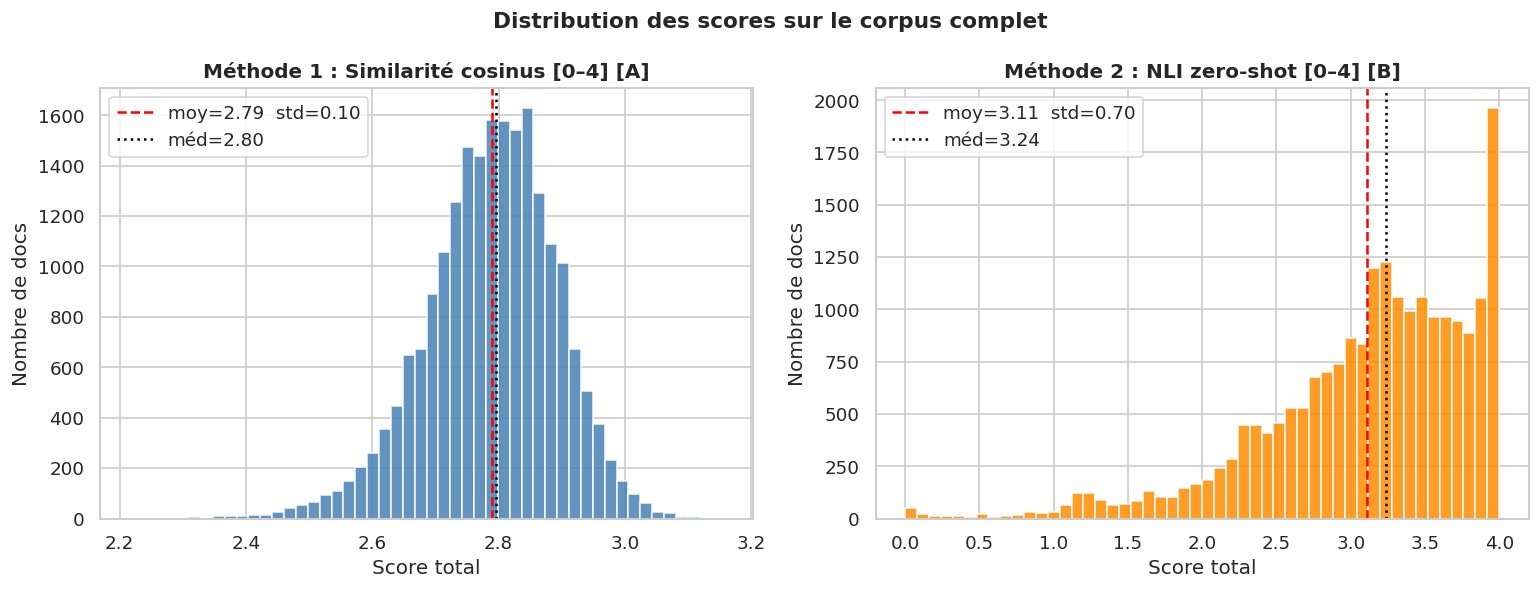

In [21]:
emb_std = scores_df['emb_total'].std()
zs_std  = scores_df['zs_total'].std()
print(f'Écart-type M1 : {emb_std:.4f}  |  M2 : {zs_std:.4f}  (ratio M2/M1 = {zs_std/emb_std:.2f}x)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, label, color in [
    (axes[0], 'emb_total', 'Méthode 1 : Similarité cosinus [0–4] [A]', 'steelblue'),
    (axes[1], 'zs_total',  'Méthode 2 : NLI zero-shot [0–4] [B]', 'darkorange'),
]:
    moy = scores_df[col].mean()
    med = scores_df[col].median()
    ax.hist(scores_df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(moy, color='red',    linestyle='--', label=f"moy={moy:.2f}  std={scores_df[col].std():.2f}")
    ax.axvline(med, color='black',  linestyle=':',  label=f"méd={med:.2f}")
    ax.set_title(label, fontweight='bold'); ax.set_xlabel('Score total'); ax.set_ylabel('Nombre de docs'); ax.legend()
plt.suptitle('Distribution des scores sur le corpus complet', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Résultats : Extrêmes vs Mainstream

In [11]:
viz_df = scores_df[scores_df['famille'].notna() & (scores_df['nb_mots'] > 30)].copy()
viz_df['famille'] = pd.Categorical(viz_df['famille'], categories=ORDRE_FAMILLES, ordered=True)
fam_in = [f for f in ORDRE_FAMILLES if f in viz_df['famille'].values]
dims_cols = ['zs_peuple', 'zs_elite', 'zs_souverainete', 'zs_manicheisme']
dim_labels_court = ['Peuple', 'Élite', 'Souveraineté', 'Manichéisme']
print(f'Documents pour visualisation : {len(viz_df)}')
print(viz_df['famille'].value_counts().reindex(ORDRE_FAMILLES))

Documents pour visualisation : 16130
famille
Extrême gauche    4417
Gauche            4966
Centre            2062
Droite            3026
Extrême droite    1659
Name: count, dtype: int64


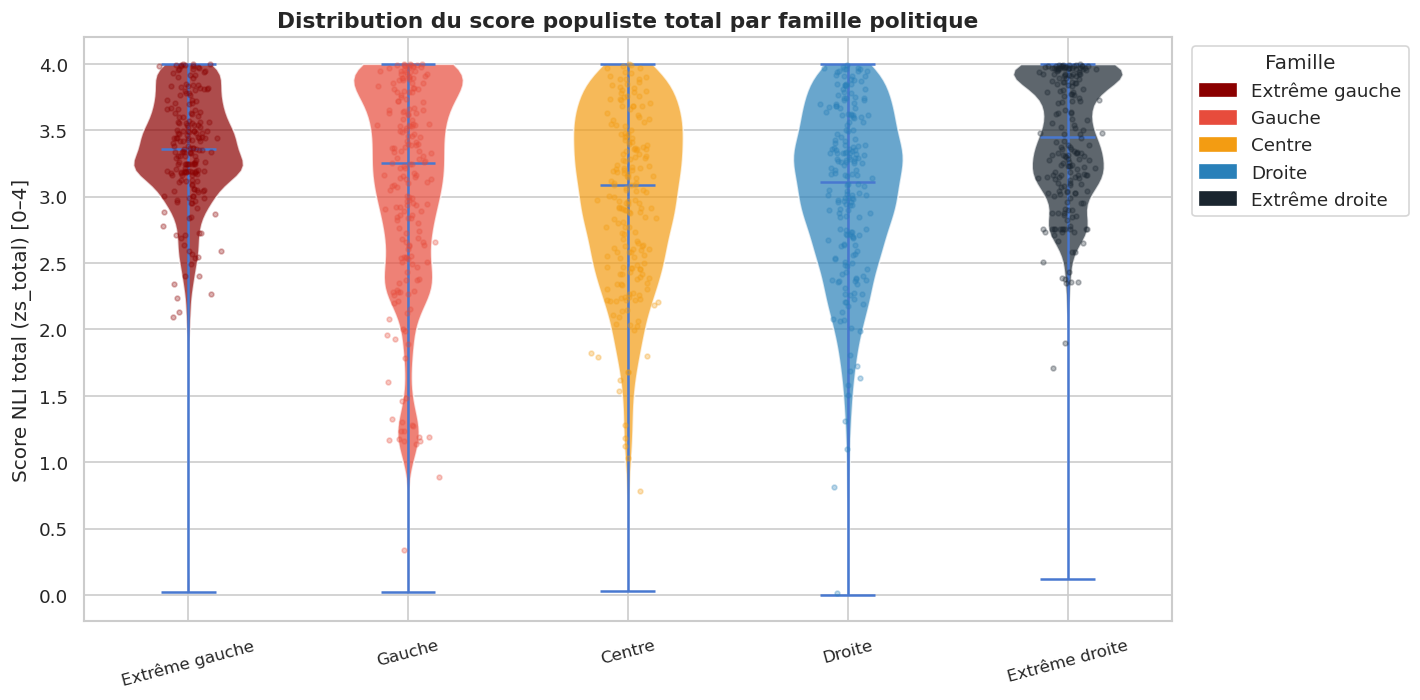

In [12]:

fig, ax = plt.subplots(figsize=(12, 6))
parts = ax.violinplot(
    [viz_df[viz_df['famille']==f]['zs_total'].dropna().values for f in fam_in],
    positions=range(len(fam_in)), showmedians=True, showextrema=True)
for pc, fam in zip(parts['bodies'], fam_in):
    pc.set_facecolor(COULEURS_5[fam]); pc.set_alpha(0.7)
np.random.seed(SEED)
for i, fam in enumerate(fam_in):
    vals = viz_df[viz_df['famille']==fam]['zs_total'].dropna().values
    sub_vals = np.random.choice(vals, min(200, len(vals)), replace=False)
    ax.scatter(np.random.normal(i, 0.05, len(sub_vals)), sub_vals,
               color=COULEURS_5[fam], alpha=0.3, s=8, zorder=3)
ax.set_xticks(range(len(fam_in))); ax.set_xticklabels(fam_in, rotation=15, fontsize=10)
ax.set_ylabel('Score NLI total (zs_total) [0–4]')
ax.set_title('Distribution du score populiste total par famille politique', fontsize=13, fontweight='bold')
patches = [mpatches.Patch(color=COULEURS_5[f], label=f) for f in fam_in]
ax.legend(handles=patches, title='Famille', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout(); plt.show()

**Lecture** : Les violins et ridge plots révèlent la forme des distributions (asymétrie, queue droite). Le barplot avec IC bootstrap 95% quantifie l'incertitude sur les moyennes sans supposer la normalité. Les familles extrêmes présentent typiquement des distributions plus étalées vers les valeurs élevées.

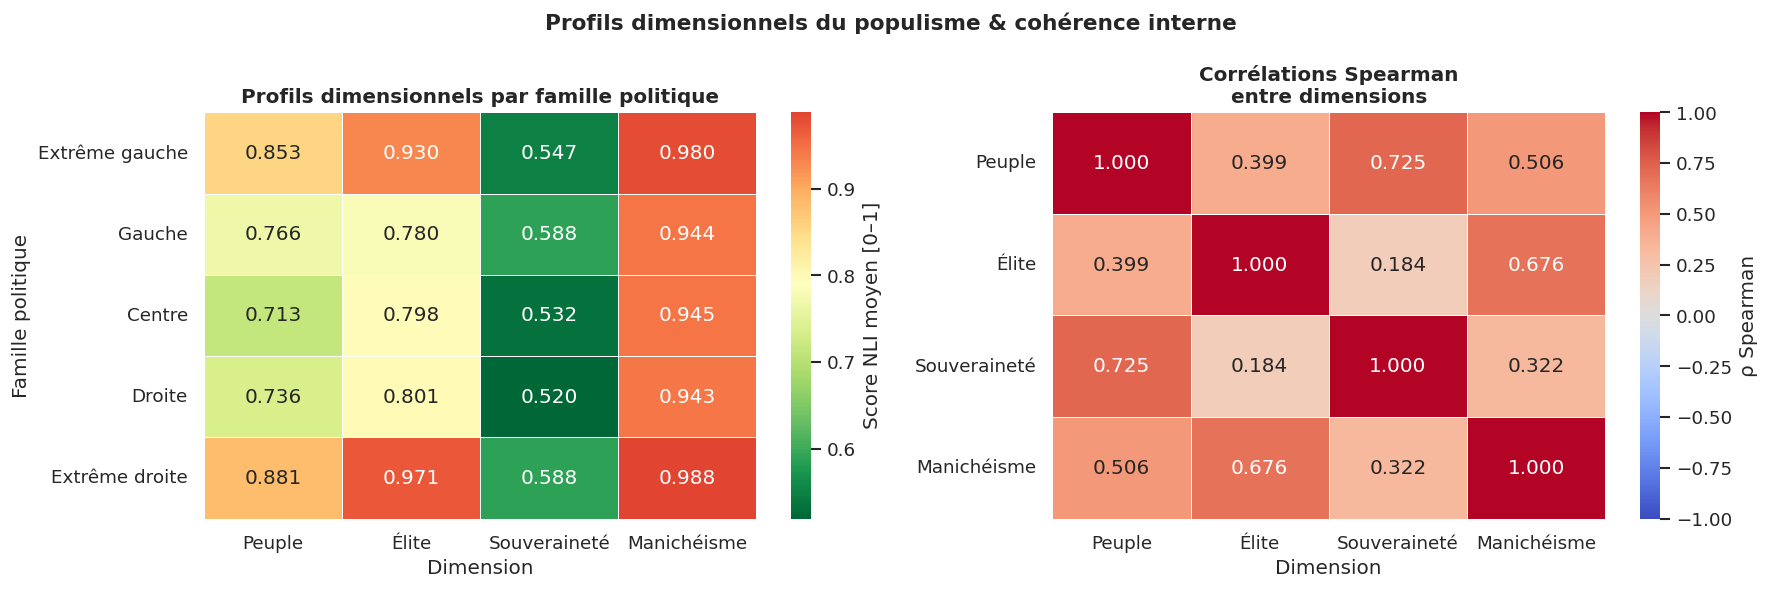

In [13]:

mean_by_fam = (viz_df.groupby('famille', observed=True)[dims_cols]
               .mean().reindex(ORDRE_FAMILLES).dropna(how='all'))
mean_by_fam.columns = dim_labels_court

corr_matrix = (viz_df[dims_cols]
               .rename(columns=dict(zip(dims_cols, dim_labels_court)))
               .corr(method='spearman'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(mean_by_fam, annot=True, fmt='.3f', cmap='RdYlGn_r',
            center=mean_by_fam.values.mean(), linewidths=0.5, linecolor='white',
            ax=axes[0], cbar_kws={'label': 'Score NLI moyen [0–1]'})
axes[0].set_title('Profils dimensionnels par famille politique', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dimension'); axes[0].set_ylabel('Famille politique')

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            ax=axes[1], cbar_kws={'label': 'ρ Spearman'})
axes[1].set_title('Corrélations Spearman\nentre dimensions', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dimension'); axes[1].set_ylabel('')

plt.suptitle('Profils dimensionnels du populisme & cohérence interne', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Lecture** : La heatmap et les radars révèlent des profils distincts. L'extrême droite présente souvent un score élevé sur Élite et Manichéisme (rhétorique anti-establishment), tandis que l'extrême gauche peut scorer davantage sur Peuple et Souveraineté (appel à la démocratie directe). Ces profils différenciés valident l'opérationnalisation multi-dimensionnelle.

Des corrélations modérées (ρ ≈ 0.3–0.6) entre dimensions indiquent qu'elles mesurent des facettes distinctes mais liées du populisme — ce qui valide l'approche multi-dimensionnelle. Des corrélations trop faibles (< 0.1) pourraient signaler que certaines dimensions captent du bruit.

## 5. Résultats : Évolution temporelle

In [14]:
pop_time = (viz_df.groupby(['annee','famille'], observed=True)['zs_total']
            .agg(['mean','count','std']).reset_index())
pop_time.columns = ['annee','famille','mean_score','n_docs','std_score']
print('Points temporels disponibles par famille :')
print(pop_time[pop_time['n_docs'] >= 5].groupby('famille')['annee'].apply(list).to_string())

Points temporels disponibles par famille :
famille
Extrême gauche    [1973, 1978, 1981, 1988, 1993]
Gauche            [1973, 1978, 1981, 1988, 1993]
Centre            [1973, 1978, 1981, 1988, 1993]
Droite            [1973, 1978, 1981, 1988, 1993]
Extrême droite    [1973, 1978, 1981, 1988, 1993]


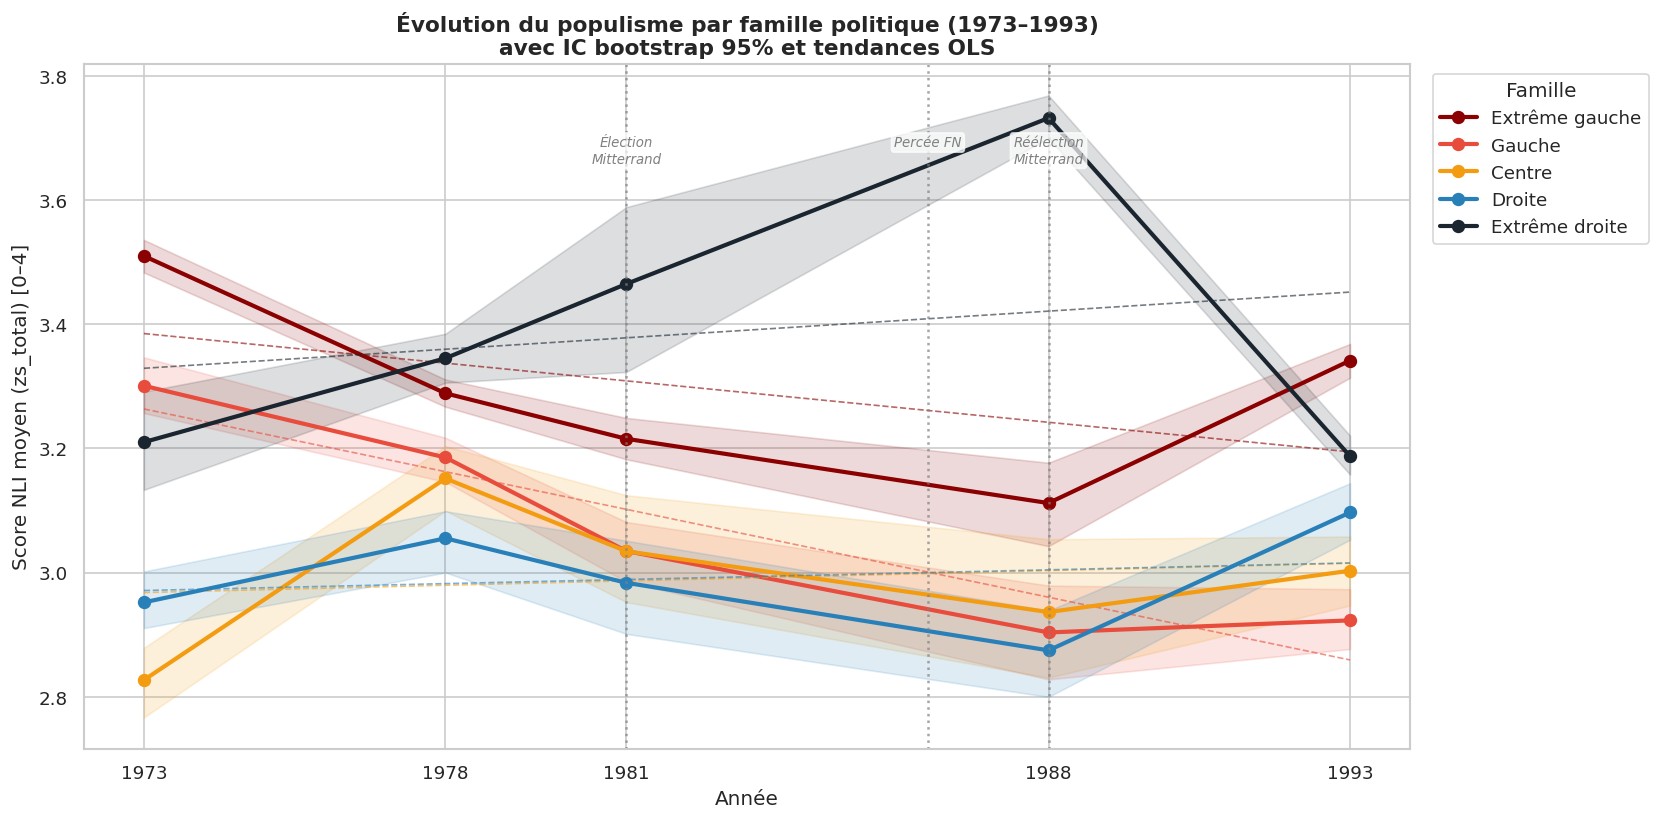

In [15]:

EVENEMENTS = {1981: 'Élection\nMitterrand', 1986: 'Percée FN', 1988: 'Réélection\nMitterrand'}

fig, ax = plt.subplots(figsize=(14, 7))
np.random.seed(SEED)
for fam in ORDRE_FAMILLES:
    sub_agg = pop_time[pop_time['famille']==fam].sort_values('annee')
    if len(sub_agg) < 2: continue
    annees_fam = sub_agg['annee'].values
    means_fam  = sub_agg['mean_score'].values
    ci_lo_list, ci_hi_list = [], []
    for annee_val in annees_fam:
        vals = viz_df[(viz_df['famille']==fam) & (viz_df['annee']==annee_val)]['zs_total'].dropna().values
        if len(vals) < 5: ci_lo_list.append(np.nan); ci_hi_list.append(np.nan); continue
        boot_m = [np.mean(np.random.choice(vals, len(vals), replace=True)) for _ in range(500)]
        ci_lo_list.append(np.percentile(boot_m, 2.5)); ci_hi_list.append(np.percentile(boot_m, 97.5))
    ci_lo_arr = np.array(ci_lo_list, dtype=float)
    ci_hi_arr = np.array(ci_hi_list, dtype=float)
    ax.plot(annees_fam, means_fam, 'o-', linewidth=2.5, color=COULEURS_5[fam], label=fam, markersize=7)
    mask = ~np.isnan(ci_lo_arr)
    if mask.sum() >= 2:
        ax.fill_between(annees_fam[mask], ci_lo_arr[mask], ci_hi_arr[mask], alpha=0.15, color=COULEURS_5[fam])
    if len(annees_fam) >= 3:
        sl, ic, *_ = sp_stats.linregress(annees_fam, means_fam)
        ax.plot([annees_fam.min(), annees_fam.max()],
                [sl*annees_fam.min()+ic, sl*annees_fam.max()+ic],
                '--', color=COULEURS_5[fam], linewidth=1, alpha=0.6)

ymin, ymax = ax.get_ylim()
for yr, label in EVENEMENTS.items():
    ax.axvline(yr, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(yr, ymax*0.97, label, ha='center', va='top', fontsize=8,
            color='gray', fontstyle='italic', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_xlabel('Année', fontsize=12); ax.set_ylabel('Score NLI moyen (zs_total) [0–4]', fontsize=12)
ax.set_title('Évolution du populisme par famille politique (1973–1993)\navec IC bootstrap 95% et tendances OLS', fontsize=13, fontweight='bold')
ax.legend(title='Famille', bbox_to_anchor=(1.01,1), loc='upper left'); ax.set_xticks(YEARS_AVAILABLE)
plt.tight_layout(); plt.show()

**Lecture** : Les lignes continues montrent les scores moyens; les bandes représentent l'IC bootstrap 95%. Les pointillés indiquent la tendance OLS. L'élection de 1981 et la percée du FN en 1986 sont des points d'inflexion potentiels à observer.

## 6. Annexe : Robustesse

Sous-échantillon robustesse : 500 documents
  1330 chunks | moy=2.7/doc
  Dimension peuple — 3 variantes scorées (chunking + max)
  Dimension elite — 3 variantes scorées (chunking + max)
  Dimension souverainete — 3 variantes scorées (chunking + max)
  Dimension manicheisme — 3 variantes scorées (chunking + max)


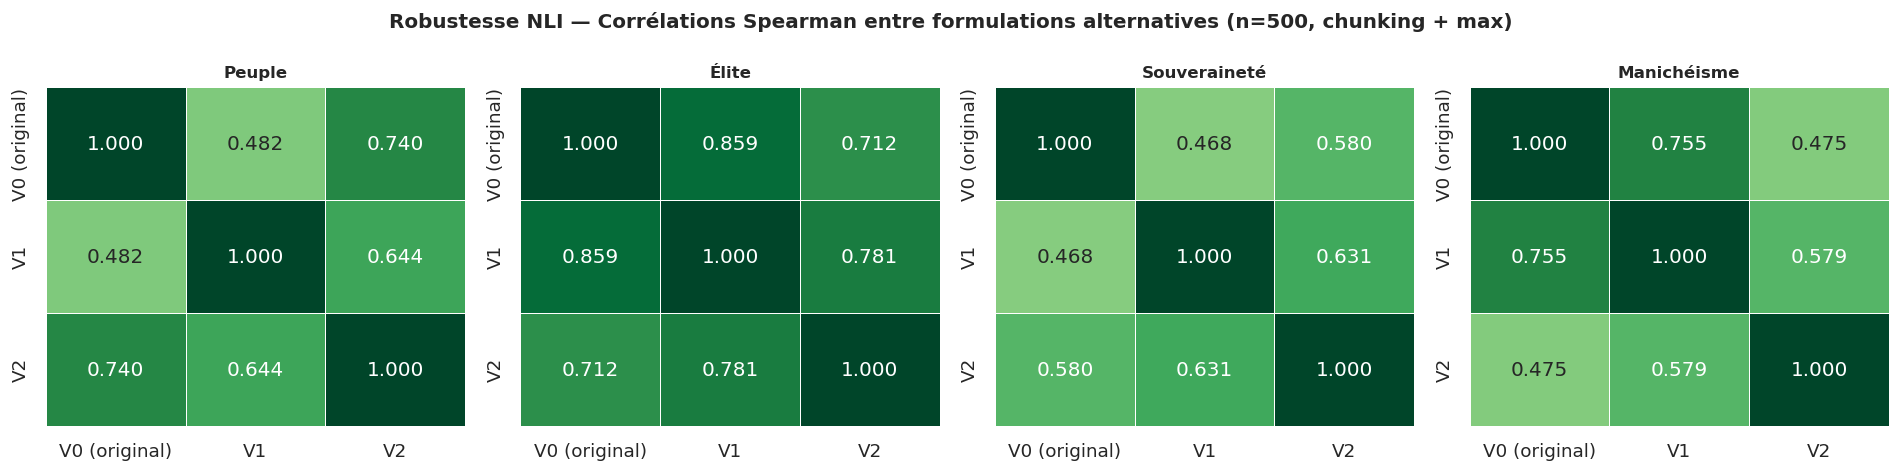


=== Corrélations Spearman min / moy par dimension ===
  Peuple          : min=0.482  moy=0.622
  Élite           : min=0.712  moy=0.784
  Souveraineté    : min=0.468  moy=0.560
  Manichéisme     : min=0.475  moy=0.603


In [16]:

HYPOTHESES_VARIANTES = {
    'peuple': [
        'Ce texte fait appel au peuple et à la volonté populaire.',
        'Ce texte glorifie le peuple comme source de légitimité.',
        'Ce texte défend les intérêts du peuple ordinaire.',
    ],
    'elite': [
        'Ce texte critique les élites politiques et leur pouvoir.',
        'Ce texte dénonce la classe politique dirigeante.',
        "Ce texte accuse les élites d'être corrompues ou incompétentes.",
    ],
    'souverainete': [
        'Ce texte défend la souveraineté populaire et la démocratie directe.',
        'Ce texte réclame plus de démocratie directe ou référendaire.',
        'Ce texte appelle à restituer le pouvoir aux citoyens.',
    ],
    'manicheisme': [
        'Ce texte présente la politique comme une lutte entre le bien et le mal.',
        'Ce texte oppose le peuple honnête aux élites corrompues.',
        'Ce texte utilise une rhétorique binaire peuple contre élites.',
    ],
}

SEUIL_SAMPLE_ROBUST = 500
np.random.seed(SEED)
idx_sample    = np.random.choice(len(viz_df), min(SEUIL_SAMPLE_ROBUST, len(viz_df)), replace=False)
sample_robust = viz_df.iloc[idx_sample].copy().reset_index(drop=True)
textes_sample = [pretraiter(TEXT_CACHE.get(str(doc_id), '')) for doc_id in sample_robust['id']]
print(f'Sous-échantillon robustesse : {len(sample_robust)} documents')

# Pré-chunking du sous-échantillon (cohérent avec la méthode principale)
chunks_sample    = [decouper_en_chunks(t, max_mots=MAX_MOTS_CHUNK) or ['.'] for t in textes_sample]
n_chunks_sample  = [len(c) for c in chunks_sample]
all_chunks_rob   = [ch for doc in chunks_sample for ch in doc]
print(f'  {len(all_chunks_rob)} chunks | moy={sum(n_chunks_sample)/len(n_chunks_sample):.1f}/doc')

def scorer_variante_chunks_max(all_chunks_list, n_chunks_list, classifier, hyp, batch_size=32):
    """Score une variante d'hypothèse sur tous les chunks, agrège par max par document."""
    # Score par batch sur tous les chunks
    scores_chunks_flat = []
    for start in range(0, len(all_chunks_list), batch_size):
        batch = all_chunks_list[start:start + batch_size]
        out   = classifier(batch, [hyp], multi_label=True)
        if isinstance(out, dict): out = [out]
        scores_chunks_flat.extend(float(o['scores'][0]) for o in out)
    # Agrégation max par document
    doc_scores, curseur = [], 0
    for n_ch in n_chunks_list:
        doc_scores.append(max(scores_chunks_flat[curseur:curseur + n_ch]))
        curseur += n_ch
    return doc_scores

scores_variantes = {}
for dim in DIMS:
    scores_variantes[dim] = {}
    for v_idx, hyp in enumerate(HYPOTHESES_VARIANTES[dim]):
        scores_variantes[dim][f'V{v_idx}'] = scorer_variante_chunks_max(
            all_chunks_rob, n_chunks_sample, zero_shot, hyp)
    print(f'  Dimension {dim} — {len(HYPOTHESES_VARIANTES[dim])} variantes scorées (chunking + max)')

labels_variantes = ['V0 (original)', 'V1', 'V2']
fig, axes = plt.subplots(1, len(DIMS), figsize=(16, 4))
for ax, dim, dim_label in zip(axes, DIMS, DIM_LABELS):
    df_var = pd.DataFrame(scores_variantes[dim])
    df_var.columns = labels_variantes[:df_var.shape[1]]
    corr_var = df_var.corr(method='spearman')
    sns.heatmap(corr_var, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1,
                ax=ax, cbar=False, linewidths=0.5)
    ax.set_title(f'{dim_label}', fontweight='bold', fontsize=10)

plt.suptitle(f'Robustesse NLI — Corrélations Spearman entre formulations alternatives (n={len(sample_robust)}, chunking + max)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n=== Corrélations Spearman min / moy par dimension ===')
for dim, dim_label in zip(DIMS, DIM_LABELS):
    df_var = pd.DataFrame(scores_variantes[dim])
    upper  = df_var.corr(method='spearman').values[np.triu_indices(df_var.shape[1], k=1)]
    print(f'  {dim_label:15s} : min={upper.min():.3f}  moy={upper.mean():.3f}')

**Lecture** : Des corrélations Spearman élevées (> 0.7) entre formulations alternatives confirment que les résultats ne dépendent pas du choix exact des hypothèses. Une robustesse élevée (ρ > 0.8 en moyenne) renforce la validité de la mesure NLI.

## 7. Annexe : Analyse par composantes principales

ACP sur 21167 documents — 4 dimensions NLI

Composante    Valeur propre (λ)  Inertie (%)  Cumulée (%)
──────────────────────────────────────────────────────────
  CP1                     2.4333        60.8%        60.8%
  CP2                     0.8774        21.9%        82.8%
  CP3                     0.4155        10.4%        93.2%
  CP4                     0.2740         6.8%       100.0%


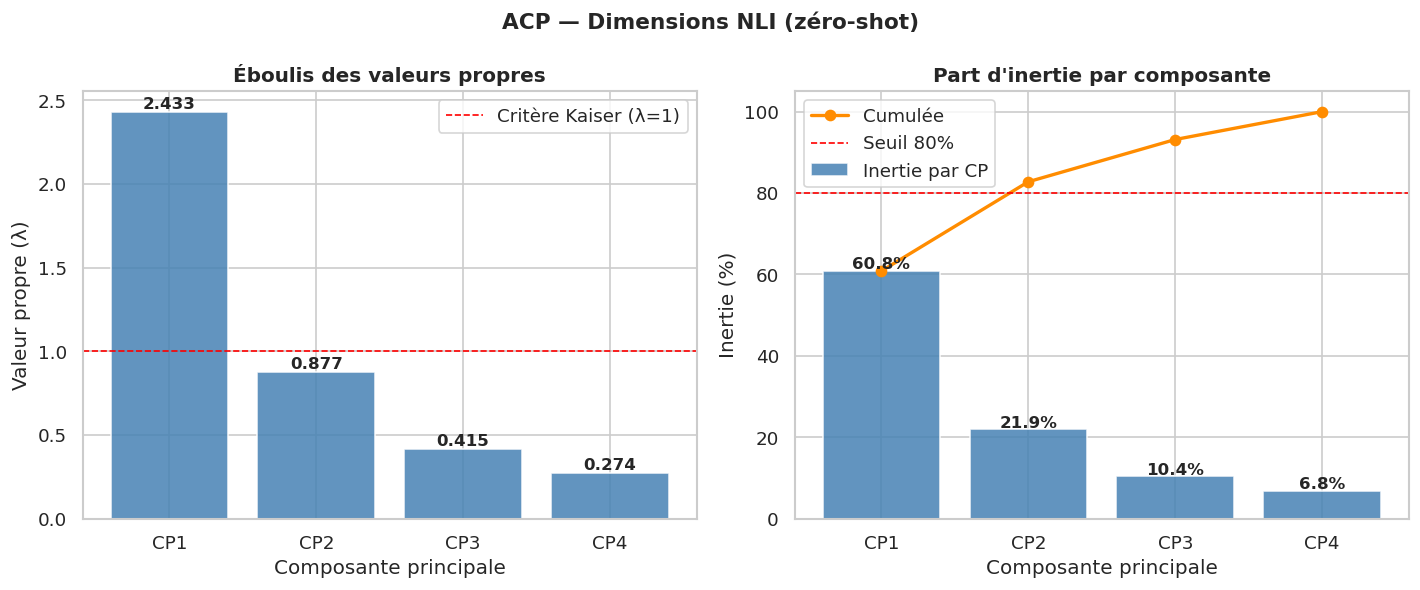

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

DIMS_ZS = ['zs_peuple', 'zs_elite', 'zs_souverainete', 'zs_manicheisme']
LABELS  = ['Peuple', 'Élite', 'Souveraineté', 'Manichéisme']

data = scores_df[DIMS_ZS].dropna()
n    = len(data)

# ── Centrage-réduction (obligatoire avant ACP) ────────────────────────────────
scaler = StandardScaler()
X      = scaler.fit_transform(data)

# ── ACP ───────────────────────────────────────────────────────────────────────
pca          = PCA(n_components=4)
pca.fit(X)

valeurs_propres = pca.explained_variance_          # λ₁, λ₂, λ₃, λ₄
inertie_pct     = pca.explained_variance_ratio_ * 100
inertie_cum     = np.cumsum(inertie_pct)

print(f"ACP sur {n} documents — {len(DIMS_ZS)} dimensions NLI\n")
print(f"{'Composante':<12} {'Valeur propre (λ)':>18} {'Inertie (%)':>12} {'Cumulée (%)':>12}")
print("─" * 58)
for k in range(4):
    print(f"  CP{k+1:<9} {valeurs_propres[k]:>18.4f} {inertie_pct[k]:>11.1f}% {inertie_cum[k]:>11.1f}%")

# ── Graphique : éboulis + inertie cumulée ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# G1 : éboulis des valeurs propres
axes[0].bar(range(1, 5), valeurs_propres, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axhline(1, color='red', linestyle='--', linewidth=1, label='Critère Kaiser (λ=1)')
axes[0].set_xticks(range(1, 5))
axes[0].set_xticklabels([f'CP{k}' for k in range(1, 5)])
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Valeur propre (λ)')
axes[0].set_title('Éboulis des valeurs propres', fontweight='bold')
axes[0].legend()
for k, lam in enumerate(valeurs_propres):
    axes[0].text(k+1, lam + 0.02, f'{lam:.3f}', ha='center', fontsize=10, fontweight='bold')

# G2 : inertie cumulée
axes[1].bar(range(1, 5), inertie_pct, color='steelblue', alpha=0.85, edgecolor='white', label='Inertie par CP')
axes[1].plot(range(1, 5), inertie_cum, color='darkorange', marker='o', linewidth=2, label='Cumulée')
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='Seuil 80%')
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels([f'CP{k}' for k in range(1, 5)])
axes[1].set_xlabel('Composante principale')
axes[1].set_ylabel('Inertie (%)')
axes[1].set_title('Part d\'inertie par composante', fontweight='bold')
axes[1].legend()
for k, (pct, cum) in enumerate(zip(inertie_pct, inertie_cum)):
    axes[1].text(k+1, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('ACP — Dimensions NLI (zéro-shot)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

ACP sur ln(1−x) — 21167 documents

Composante    Valeur propre (λ)  Inertie (%)  Cumulée (%)
──────────────────────────────────────────────────────────
  CP1                     2.4440        61.1%        61.1%
  CP2                     0.9797        24.5%        85.6%
  CP3                     0.3179         7.9%        93.5%
  CP4                     0.2586         6.5%       100.0%


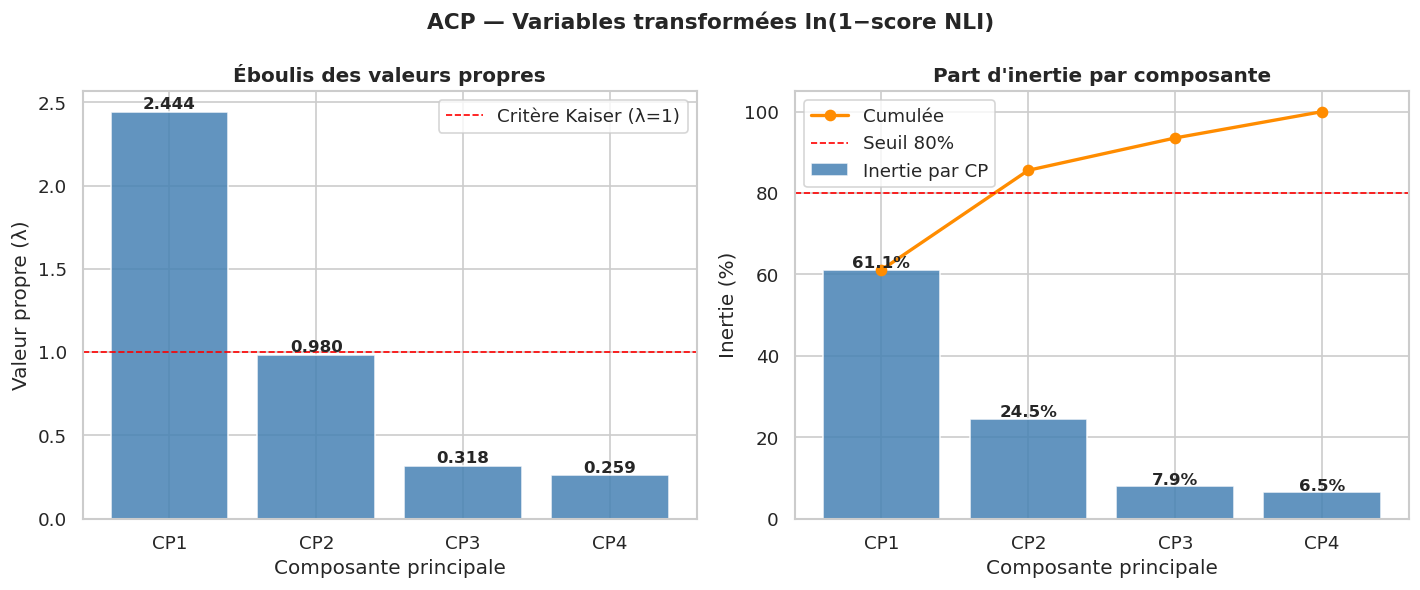

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2
import numpy as np

DIMS_ZS = ['zs_peuple', 'zs_elite', 'zs_souverainete', 'zs_manicheisme']
LABELS  = ['Peuple', 'Élite', 'Souveraineté', 'Manichéisme']

eps      = 1e-6
data_raw = scores_df[DIMS_ZS].dropna().clip(upper=1 - eps)
data_log = np.log(1 - data_raw)
n        = len(data_log)

scaler2 = StandardScaler()
X2      = scaler2.fit_transform(data_log)

pca2             = PCA(n_components=4)
pca2.fit(X2)
valeurs_propres2 = pca2.explained_variance_
inertie_pct2     = pca2.explained_variance_ratio_ * 100
inertie_cum2     = np.cumsum(inertie_pct2)

print(f"ACP sur ln(1−x) — {n} documents\n")
print(f"{'Composante':<12} {'Valeur propre (λ)':>18} {'Inertie (%)':>12} {'Cumulée (%)':>12}")
print("─" * 58)
for k in range(4):
    print(f"  CP{k+1:<9} {valeurs_propres2[k]:>18.4f} {inertie_pct2[k]:>11.1f}% {inertie_cum2[k]:>11.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, 5), valeurs_propres2, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axhline(1, color='red', linestyle='--', linewidth=1, label='Critère Kaiser (λ=1)')
axes[0].set_xticks(range(1, 5)); axes[0].set_xticklabels([f'CP{k}' for k in range(1, 5)])
axes[0].set_xlabel('Composante principale'); axes[0].set_ylabel('Valeur propre (λ)')
axes[0].set_title('Éboulis des valeurs propres', fontweight='bold'); axes[0].legend()
for k, lam in enumerate(valeurs_propres2):
    axes[0].text(k+1, lam + 0.02, f'{lam:.3f}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(range(1, 5), inertie_pct2, color='steelblue', alpha=0.85, edgecolor='white', label='Inertie par CP')
axes[1].plot(range(1, 5), inertie_cum2, color='darkorange', marker='o', linewidth=2, label='Cumulée')
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='Seuil 80%')
axes[1].set_xticks(range(1, 5)); axes[1].set_xticklabels([f'CP{k}' for k in range(1, 5)])
axes[1].set_xlabel('Composante principale'); axes[1].set_ylabel('Inertie (%)')
axes[1].set_title("Part d'inertie par composante", fontweight='bold'); axes[1].legend()
for k, pct in enumerate(inertie_pct2):
    axes[1].text(k+1, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('ACP — Variables transformées ln(1−score NLI)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

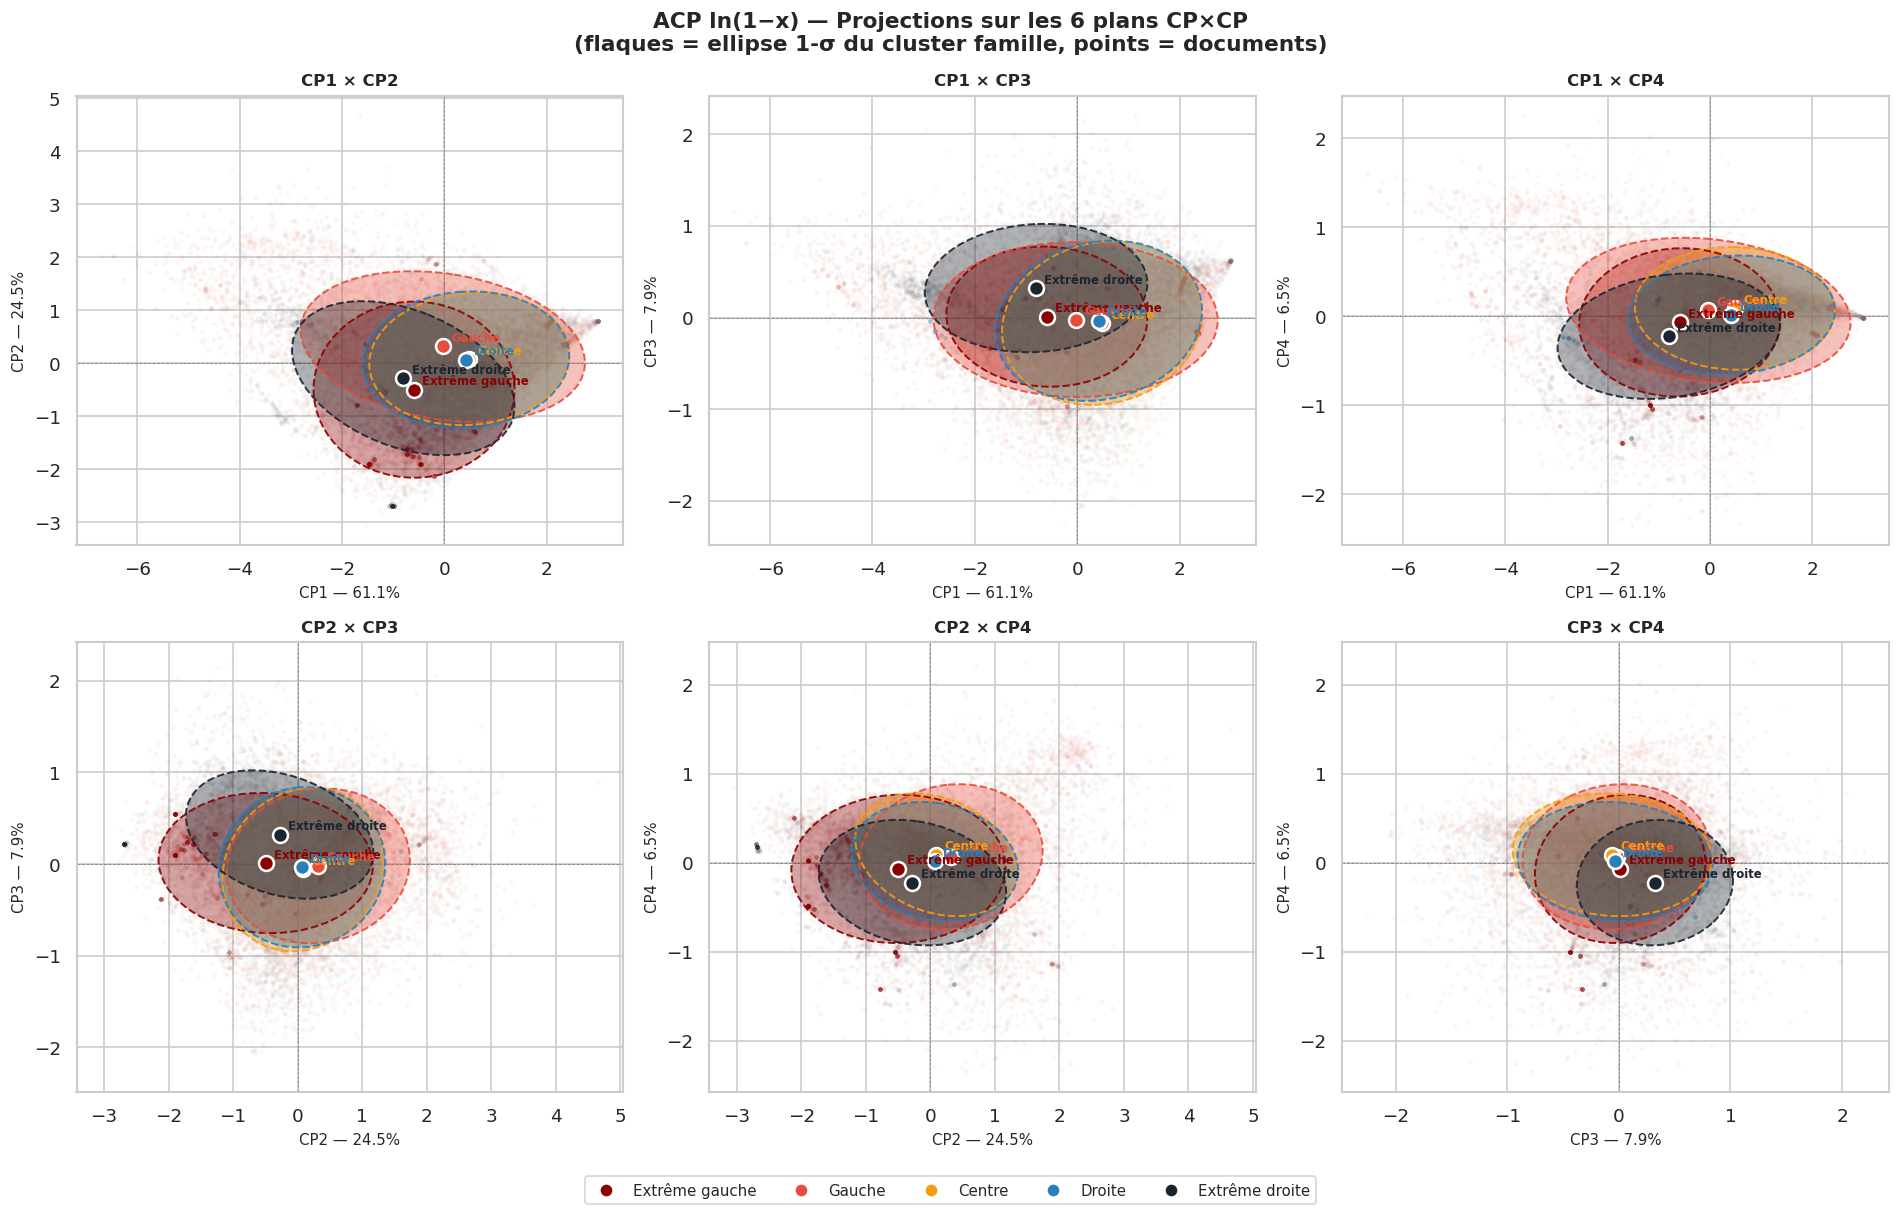

In [27]:
from itertools import combinations
from matplotlib.patches import Ellipse

def ellipse_distribution(x, y, ax, confiance=0.68, **kwargs):
    cov  = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    scale  = np.sqrt(chi2.ppf(confiance, df=2))
    width  = 2 * scale * np.sqrt(vals[1])
    height = 2 * scale * np.sqrt(vals[0])
    angle  = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    ax.add_patch(Ellipse((np.mean(x), np.mean(y)),
                         width=width, height=height, angle=angle, **kwargs))

paires   = list(combinations(range(4), 2))
X2_pca   = pca2.transform(X2)
pca_full = data_log.copy()
for k in range(4):
    pca_full[f'CP{k+1}'] = X2_pca[:, k]
pca_full['famille'] = scores_df.loc[data_log.index, 'famille']
viz = pca_full[pca_full['famille'].notna()].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (i, j) in zip(axes, paires):
    xi, xj = f'CP{i+1}', f'CP{j+1}'

    for fam in ORDRE_FAMILLES:
        sub = viz[viz['famille'] == fam]
        ax.scatter(sub[xi], sub[xj], color=COULEURS_5[fam], alpha=0.04, s=8, linewidths=0)

    for fam in ORDRE_FAMILLES:
        sub = viz[viz['famille'] == fam]
        if len(sub) < 3: continue
        x_vals, y_vals = sub[xi].values, sub[xj].values
        cx, cy = x_vals.mean(), y_vals.mean()
        ellipse_distribution(x_vals, y_vals, ax, facecolor=COULEURS_5[fam],
                             alpha=0.35, edgecolor='none', zorder=3)
        ellipse_distribution(x_vals, y_vals, ax, facecolor='none', alpha=0.9,
                             edgecolor=COULEURS_5[fam], linewidth=1.2,
                             linestyle='--', zorder=4)
        ax.scatter(cx, cy, color=COULEURS_5[fam], s=80,
                   edgecolors='white', linewidths=1.5, zorder=6)
        ax.annotate(fam, (cx, cy), textcoords='offset points', xytext=(5, 3),
                    fontsize=7, fontweight='bold', color=COULEURS_5[fam], zorder=7)

    ax.axhline(0, color='gray', lw=0.5, linestyle='--')
    ax.axvline(0, color='gray', lw=0.5, linestyle='--')
    ax.set_xlabel(f'{xi} — {inertie_pct2[i]:.1f}%', fontsize=9)
    ax.set_ylabel(f'{xj} — {inertie_pct2[j]:.1f}%', fontsize=9)
    ax.set_title(f'{xi} × {xj}', fontweight='bold', fontsize=10)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=COULEURS_5[f], markersize=8, label=f) for f in ORDRE_FAMILLES]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9,
           framealpha=0.8, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('ACP ln(1−x) — Projections sur les 6 plans CP×CP\n'
             '(flaques = ellipse 1-σ du cluster famille, points = documents)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.subplots_adjust(bottom=0.08); plt.show()

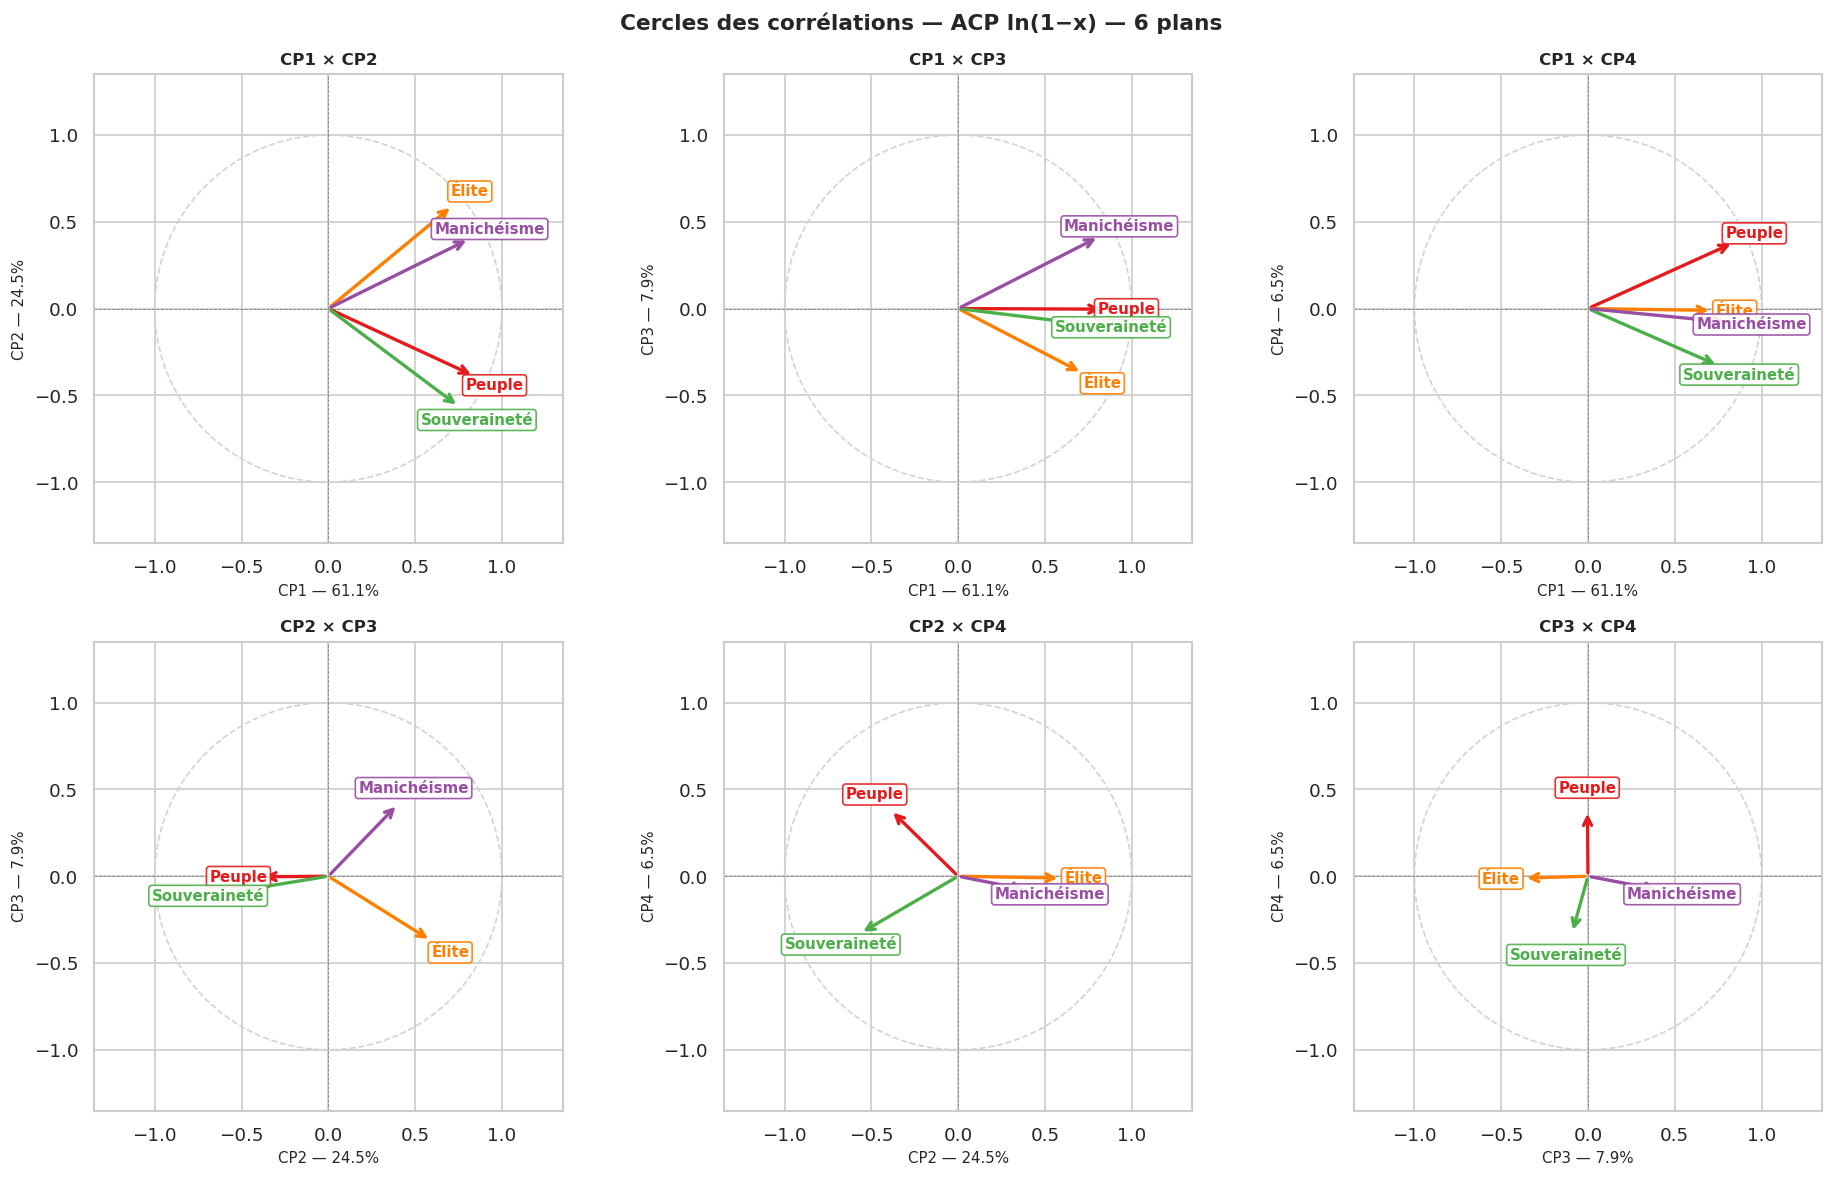

In [28]:
COULEURS_AXES = ['#e41a1c', '#ff7f00', '#4daf4a', '#984ea3']
corr_coords   = pca2.components_.T * np.sqrt(pca2.explained_variance_)  # shape (4, 4)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (i, j) in zip(axes, paires):
    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), color='lightgray', lw=1, linestyle='--')

    for k, (label, col) in enumerate(zip(LABELS, COULEURS_AXES)):
        dx, dy = corr_coords[k, i], corr_coords[k, j]
        ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=col, lw=2))
        norm = np.sqrt(dx**2 + dy**2) + 1e-9
        ox, oy = dx / norm * (norm + 0.13), dy / norm * (norm + 0.13)
        ax.text(ox, oy, label, ha='center', va='center',
                fontsize=9, fontweight='bold', color=col,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.9, ec=col, lw=1))

    ax.axhline(0, color='gray', lw=0.5, linestyle='--')
    ax.axvline(0, color='gray', lw=0.5, linestyle='--')
    ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35); ax.set_aspect('equal')
    ax.set_xlabel(f'CP{i+1} — {inertie_pct2[i]:.1f}%', fontsize=9)
    ax.set_ylabel(f'CP{j+1} — {inertie_pct2[j]:.1f}%', fontsize=9)
    ax.set_title(f'CP{i+1} × CP{j+1}', fontweight='bold', fontsize=10)

plt.suptitle('Cercles des corrélations — ACP ln(1−x) — 6 plans',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

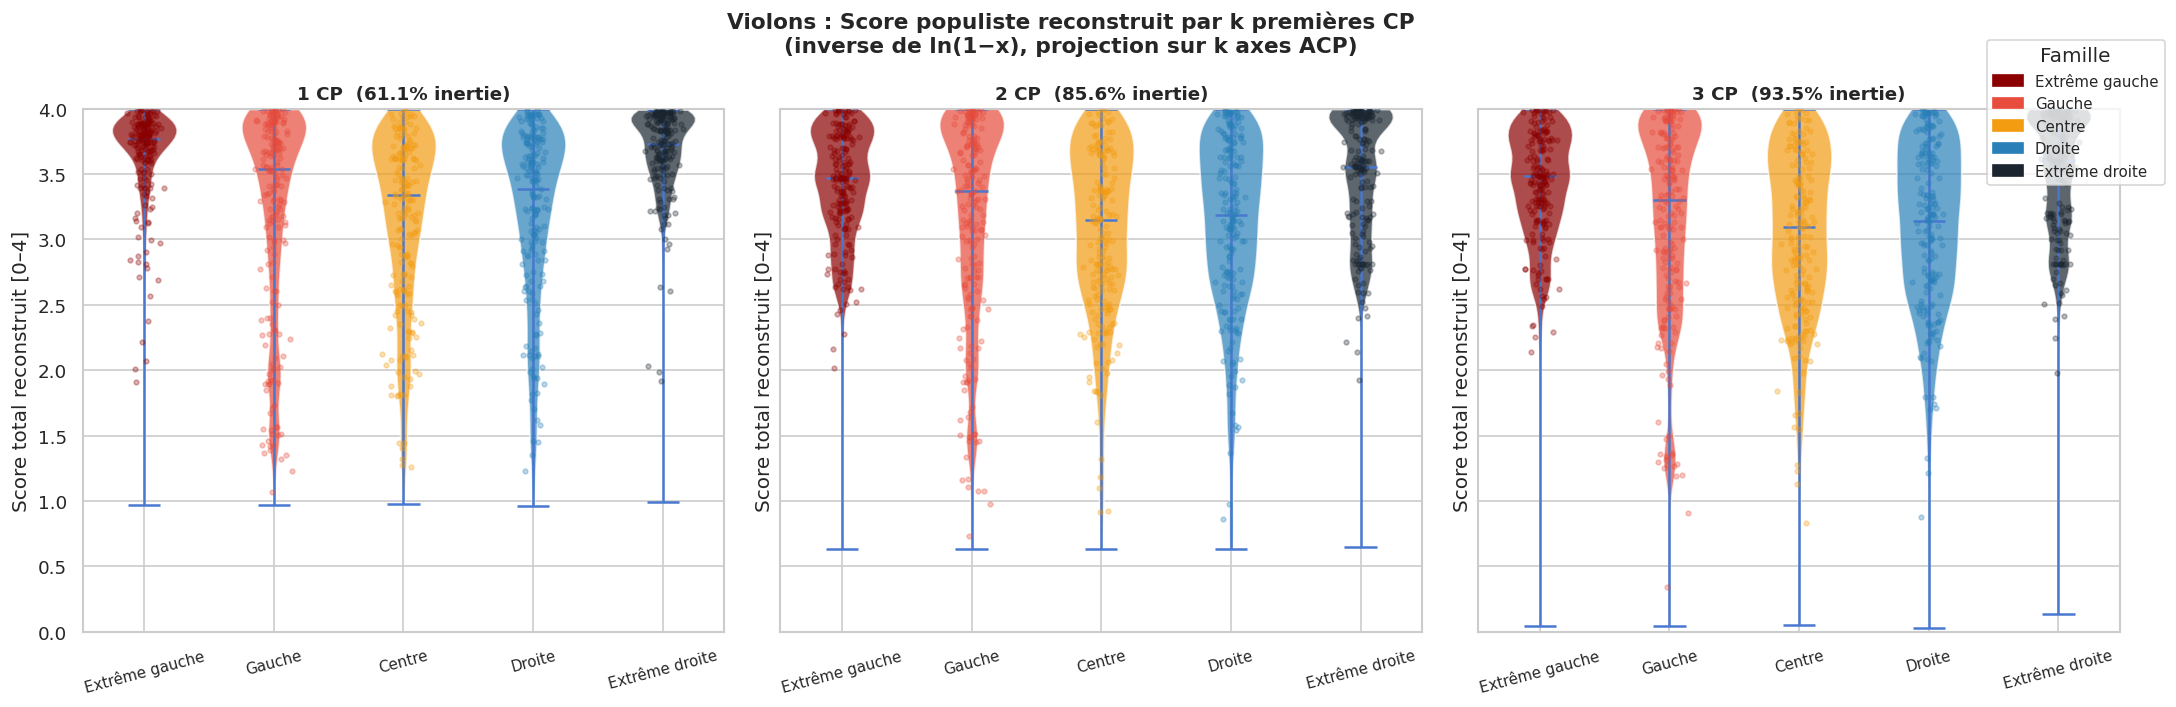

In [30]:
def score_reconstruit(k):
    X_k    = X2_pca[:, :k] @ pca2.components_[:k, :]
    X_log  = X_k * scaler2.scale_ + scaler2.mean_
    X_orig = np.clip(1 - np.exp(X_log), 0, 1)
    return X_orig.sum(axis=1)

pca_full['score_1CP'] = score_reconstruit(1)
pca_full['score_2CP'] = score_reconstruit(2)
pca_full['score_3CP'] = score_reconstruit(3)
viz_pca_full = pca_full[pca_full['famille'].notna()].copy()
fam_in = [f for f in ORDRE_FAMILLES if f in viz_pca_full['famille'].values]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, col, titre in [
    (axes[0], 'score_1CP', f'1 CP  ({inertie_pct2[0]:.1f}% inertie)'),
    (axes[1], 'score_2CP', f'2 CP  ({inertie_cum2[1]:.1f}% inertie)'),
    (axes[2], 'score_3CP', f'3 CP  ({inertie_cum2[2]:.1f}% inertie)'),
]:
    data_viol = [viz_pca_full[viz_pca_full['famille'] == f][col].dropna().values for f in fam_in]
    parts = ax.violinplot(data_viol, positions=range(len(fam_in)),
                          showmedians=True, showextrema=True)
    for pc, fam in zip(parts['bodies'], fam_in):
        pc.set_facecolor(COULEURS_5[fam]); pc.set_alpha(0.7)

    np.random.seed(SEED)
    for i, fam in enumerate(fam_in):
        vals = viz_pca_full[viz_pca_full['famille'] == fam][col].dropna().values
        sub  = np.random.choice(vals, min(200, len(vals)), replace=False)
        ax.scatter(np.random.normal(i, 0.05, len(sub)), sub,
                   color=COULEURS_5[fam], alpha=0.3, s=8, zorder=3)

    ax.set_xticks(range(len(fam_in)))
    ax.set_xticklabels(fam_in, rotation=15, fontsize=9)
    ax.set_ylim(0, 4)
    ax.set_ylabel('Score total reconstruit [0–4]')
    ax.set_title(titre, fontweight='bold', fontsize=11)

patches = [mpatches.Patch(color=COULEURS_5[f], label=f) for f in fam_in]
fig.legend(handles=patches, title='Famille', loc='upper right',
           bbox_to_anchor=(1.01, 0.95), fontsize=9)
plt.suptitle('Violons : Score populiste reconstruit par k premières CP\n'
             '(inverse de ln(1−x), projection sur k axes ACP)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()